### Directional Splitting



In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def vorticity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    return 2*np.sin(x)*np.sin(y)*decay

In [3]:
def m4prime_1d(s):
    """
    Monaghan's M4' remeshing kernel (paper Eq. 53-54):

        W(s) = 1 - 5/2 |s|^2 + 3/2 |s|^3            for |s| <= 1
        W(s) = 1/2 (1-|s|)(2-|s|)^2                  for 1 <= |s| <= 2
        W(s) = 0                                      otherwise

    Piecewise cubic, C^1, support [-2, 2], order p=2 (conserves circulation,
    linear impulse and angular impulse).
    """
    s = np.abs(np.asarray(s, dtype=float))
    w = np.zeros_like(s)

    m1 = s <= 1.0
    m2 = (s > 1.0) & (s <= 2.0)

    w[m1] = 1 - 5/2 * s[m1] ** 2 + 3/2 * s[m1] ** 3
    w[m2] = 1/2 * (1 - s[m2]) * (2 - s[m2]) ** 2
    #w[m1] = 1.0 - 1 * s[m1] ** 2 - 4.5 * s[m1] ** 3 + 7.5 * s[m1] ** 4 - 3 * s[m1] ** 5
    #w[m2] = -4 + 18 * s[m2] ** 1  - 29 * s[m2] ** 2 + (43/2) * s[m2] ** 3 -  7.5 * s[m2] ** 4 + 1 * s[m2] ** 5
    return w

In [4]:
m4prime_1d(np.array([0, 1, -1, 2, -2]))

array([ 1.,  0.,  0., -0., -0.])

In [7]:
"""def p2m(particles, mesh, h):

    Nx, Ny = mesh.shape
    mesh.fill(0.0)

    for p in particles:
        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # Base index of the cell the particle sits in
        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        # M4' has support [-2h, 2h], so stencil spans i0-1 to i0+2 (4 nodes)
        for di in range(-1, 3):
            for dj in range(-1, 3):
                ig = (i0 + di) % Nx
                jg = (j0 + dj) % Ny

                # Normalised distances in x and y separately
                sx = (xp - (i0 + di) * h) / h
                sy = (yp - (j0 + dj) * h) / h

                # 2D kernel is tensor product of two 1D kernels
                w = m4prime_1d(sx) * m4prime_1d(sy)

                mesh[ig, jg] += w * p["a"] / h**2

    return mesh
"""

def p2m(particles, mesh, h):

    Nx, Ny = mesh.shape
    mesh.fill(0.0)

    for p in particles:
        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = [0.0, 0.0, 0.0, 0.0]
        ix = [0, 0, 0, 0]

        for k, di in enumerate(range(-1, 3)):
            ig = (i0 + di) % Nx
            sx = (xp - (i0 + di) * h) / h
            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]
            ix[k] = ig

        wy = [0.0, 0.0, 0.0, 0.0]
        iy = [0, 0, 0, 0]

        for k, dj in enumerate(range(-1, 3)):
            jg = (j0 + dj) % Ny
            sy = (yp - (j0 + dj) * h) / h
            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]
            iy[k] = jg

        ap = p["a"] / h**2

        for k in range(4):
            ig = ix[k]
            wxk = wx[k] * ap
            for l in range(4):
                jg = iy[l]
                mesh[ig, jg] += wxk * wy[l]

    return mesh

In [6]:
def poisson_solver(omega, h):

    Nx, Ny = omega.shape

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY = np.meshgrid(kx,ky,indexing="ij")
    K2 = KX ** 2 + KY ** 2

    K2[0,0]=1.0

    omega_hat=np.fft.fft2(omega)

    psi_hat=omega_hat/K2
    psi_hat[0,0]=0.0

    psi=np.real(np.fft.ifft2(psi_hat))

    u_hat=1j*KY*psi_hat
    v_hat=-1j*KX*psi_hat

    u=np.real(np.fft.ifft2(u_hat))
    v=np.real(np.fft.ifft2(v_hat))

    U = u + 1j * v

    return U

In [9]:
def m2p(particles, mesh, h, type):

    Nx, Ny = mesh.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # -----------------------------------------------------
        # Base grid indices
        # -----------------------------------------------------

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        # -----------------------------------------------------
        # Accumulated interpolated value
        # -----------------------------------------------------

        value = 0.0

        # -----------------------------------------------------
        # M4' has support [-2h, 2h]
        # Therefore 4 x 4 = 16 grid points
        # -----------------------------------------------------

        for di in range(-1, 3):

            ig = (i0 + di) % Nx

            # Physical x-coordinate of grid node
            xg = (i0 + di) * h

            # Normalized x-distance
            sx = (xp - xg) / h

            wx = m4prime_1d(sx)

            for dj in range(-1, 3):

                jg = (j0 + dj) % Ny

                # Physical y-coordinate of grid node
                yg = (j0 + dj) * h

                # Normalized y-distance
                sy = (yp - yg) / h

                wy = m4prime_1d(sy)

                # Tensor-product kernel
                w = wx * wy

                # Mesh -> particle contribution
                value += mesh[ig, jg] * w

        # -----------------------------------------------------
        # Store result
        # -----------------------------------------------------

        if type == 'v':

            p["u"] = value

        elif type == 'w':

            # mesh contains vorticity
            # particle stores circulation
            p["a"] = value * h**2

        else:

            raise ValueError(
                "type must be 'v' or 'w'"
            )

    return particles

"""

def m2p(particles, mesh, h, type):

    Nx, Ny = mesh.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = [0.0, 0.0, 0.0, 0.0]
        ix = [0, 0, 0, 0]

        for k, di in enumerate(range(-1, 3)):
            ig = (i0 + di) % Nx
            xg = (i0 + di) * h
            sx = (xp - xg) / h
            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]
            ix[k] = ig

        wy = [0.0, 0.0, 0.0, 0.0]
        iy = [0, 0, 0, 0]

        for k, dj in enumerate(range(-1, 3)):
            jg = (j0 + dj) % Ny
            yg = (j0 + dj) * h
            sy = (yp - yg) / h
            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]
            iy[k] = jg

        value = 0.0

        for k in range(4):
            ig = ix[k]
            wxk = wx[k]
            for l in range(4):
                jg = iy[l]
                value += mesh[ig, jg] * wxk * wy[l]

        if type == 'v':
            p["u"] = value
        elif type == 'w':
            p["a"] = value * h**2
        else:
            raise ValueError("type must be 'v' or 'w'")

    return particles"""

'\n\ndef m2p(particles, mesh, h, type):\n\n    Nx, Ny = mesh.shape\n\n    for p in particles:\n\n        xp = np.real(p["pos"])\n        yp = np.imag(p["pos"])\n\n        i0 = int(np.floor(xp / h))\n        j0 = int(np.floor(yp / h))\n\n        wx = [0.0, 0.0, 0.0, 0.0]\n        ix = [0, 0, 0, 0]\n\n        for k, di in enumerate(range(-1, 3)):\n            ig = (i0 + di) % Nx\n            xg = (i0 + di) * h\n            sx = (xp - xg) / h\n            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]\n            ix[k] = ig\n\n        wy = [0.0, 0.0, 0.0, 0.0]\n        iy = [0, 0, 0, 0]\n\n        for k, dj in enumerate(range(-1, 3)):\n            jg = (j0 + dj) % Ny\n            yg = (j0 + dj) * h\n            sy = (yp - yg) / h\n            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]\n            iy[k] = jg\n\n        value = 0.0\n\n        for k in range(4):\n            ig = ix[k]\n            wxk = wx[k]\n            for l in range(4):\n                jg = iy[l]\n                value += me

In [10]:
def advect(particles, dt, Lx, Ly, dirn, dimn):

    if dimn == 1:
        for p in particles:

            if dirn == 0:
                p["pos"] += np.real(p["u"]) * dt

                x = np.real(p["pos"]) % Lx
                y = np.imag(p["pos"]) % Ly

                u = np.imag(p["u"]) * 1j

            elif dirn == 1:
                p["pos"] += p["u"] * dt

                x = np.real(p["pos"]) % Lx
                y = np.imag(p["pos"]) % Ly

                u = 0

            p["pos"] = x + 1j*y
            p['u'] = u

    elif dimn == 2:

        for p in particles:
            p['pos'] += p['u'] * dt
            p['u'] == 0
            
    return particles

In [11]:
def p2m2(particles, mesh, h):

    Nx, Ny = mesh.shape
    gamma_grid = np.array(
        [p["a"] for p in particles]
    ).reshape(Nx, Ny)

    omega_grid = gamma_grid / h**2

    return omega_grid

In [12]:
def m2p2(particles, mesh):

    Nx, Ny = mesh.shape

    # Make sure particle count matches mesh
    if len(particles) != Nx * Ny:
        raise ValueError(
            "Number of particles must equal Nx * Ny"
        )

    k = 0

    for i in range(Nx):

        for j in range(Ny):

            particles[k]["a"] = mesh[i, j]

            k += 1

    return particles

In [13]:
def diffusion_solver (omega, h):

    Nx, Ny = omega.shape

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY=np.meshgrid(kx,ky,indexing="ij")
    K2=KX**2+KY**2

    K2[0,0]=1.0


    #diffusion

    omega_hat=np.fft.fft2(omega)

    diffusion = np.exp(-nu * K2 * dt)

    omega_hat *= diffusion

    omega = np.real(np.fft.ifft2(omega_hat))

    return omega

In [14]:
def remeshing(particles, mesh, h, dirn):

    Nx, Ny = mesh.shape

    if dirn == 0:

        xp = np.array([np.real(p["pos"]) for p in particles])

        yp = np.array([np.imag(p["pos"]) for p in particles])

        gamma = np.array([p["a"] for p in particles])

        up = np.array([p["u"] for p in particles])

        # =========================================================
        # Intermediate X-remeshed circulation
        # =========================================================

        gamma_x = np.zeros((Nx, Ny), dtype=float)
        u_x = np.zeros((Nx, Ny), dtype=complex)

        # =========================================================
        # Base indices
        # =========================================================

        i0 = np.floor(xp / h).astype(int) 

        j0 = np.floor(yp / h).astype(int) % Ny

        # =========================================================
        # Four-point X stencil
        # =========================================================

        for di in range(-1, 3):

            ii = (i0 + di) % Nx

            x_grid = (i0 + di) * h

            sx = (xp - x_grid) / h

            wx = m4prime_1d(sx)

            # Accumulate Gamma * Wx
            np.add.at(gamma_x, (ii, j0), gamma * wx)
            np.add.at(u_x, (ii, j0), up * wx)

        # =========================================================
        # Reconstruct YOUR particle format
        # =========================================================

        x = np.arange(Nx) * h
        y = np.arange(Ny) * h

        X, Y = np.meshgrid(x, y, indexing="ij")

        particles_new = []

        for i in range(Nx):

            for j in range(Ny):

                particles_new.append({
                    "pos": X[i, j] + 1j * Y[i, j],
                    "a": gamma_x[i, j],
                    "u": u_x[i, j]
                })

        return particles_new


    elif dirn == 1:

        xp = np.array([np.real(p["pos"]) for p in particles])

        yp = np.array([np.imag(p["pos"]) for p in particles])

        # This is already Gamma * Wx
        gamma_x = np.array([p["a"] for p in particles])

        # =========================================================
        # Final circulation
        # =========================================================

        gamma_new = np.zeros((Nx, Ny), dtype=float)

        # =========================================================
        # Base Y index
        # =========================================================

        j0 = np.floor(yp / h).astype(int)

        # =========================================================
        # X index stays fixed
        # =========================================================

        i0 = np.floor(xp / h).astype(int) % Nx

        # =========================================================
        # Four-point Y stencil
        # =========================================================

        for dj in range(-1, 3):

            jj = (j0 + dj) % Ny

            y_grid = (j0 + dj) * h

            sy = (yp - y_grid) / h

            wy = m4prime_1d(sy)

            # =====================================================
            # IMPORTANT
            #
            # gamma_x = Gamma * Wx
            #
            # Therefore:
            #
            # gamma_x * Wy
            #
            # = Gamma * Wx * Wy
            # =====================================================

            np.add.at(gamma_new, (i0, jj), gamma_x * wy)

        # =========================================================
        # Reconstruct YOUR particle format
        # =========================================================

        x = np.arange(Nx) * h
        y = np.arange(Ny) * h

        X, Y = np.meshgrid(x, y, indexing="ij")

        particles_new = []

        for i in range(Nx):

            for j in range(Ny):

                p = {
                    "pos": X[i, j] + 1j * Y[i, j],
                    "a": gamma_new[i, j]
                }

                particles_new.append(p)

        # IMPORTANT: return the new particle list
        return particles_new  



In [15]:
#Subspace 
L = 2*np.pi
B = 2*np.pi

#Constants
#Re = 10
nu = 0.1    #0.1
T = 0.05
dt = 0.05

#Particles
Nxp = 100
Nyp = 100

h = L/Nxp

#Particles in grid
X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                  np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

#Finding vorticity of particles analytically
wm = vorticity(X,Y, 0, nu)

vmax = np.max(np.abs(vorticity(X,Y, 0, nu)))
vmin = -vmax

#Storing information in particle
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), wm.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

# Mesh
Nxm = Nxp
Nym = Nyp

mesh = np.zeros((Nxm, Nym))

flag = 1

in_flag = False

out_flag = False

In [16]:
for i in np.arange(0, T, dt):

    wm = p2m(particles, mesh, h)

    um = poisson_solver(wm, h)

    particles = m2p(particles, um, h, 'v')

    #wm = p2m2(particles, mesh, h)

    for dimn in [0, 1]:
        particles = advect(particles, dt, L, B, dimn, 1)
        #particles = remeshing(particles, mesh, h, dimn)

        #if flag % 2:
            #particles = remeshing(particles, mesh, h, dimn)

        """#in_flag = True
        if flag == 1:
            particles = remeshing(particles, mesh, h, dimn)
            out_flag = True

            if in_flag:
                flag = 0
                in_flag = False

            in_flag = True  """    

    flag += 1
    wm = p2m2(particles, mesh, h)
    wm_ = p2m(particles, mesh, h)

    """if out_flag:
        wm = p2m2(particles, mesh, h)
        out_flag = False

    else:"""
"""    wm = p2m2(particles, mesh, h)

    wm = diffusion_solver(wm, h)

    particles = m2p(particles, wm, h, 'w')"""

"    wm = p2m2(particles, mesh, h)\n\n    wm = diffusion_solver(wm, h)\n\n    particles = m2p(particles, wm, h, 'w')"

In [22]:
your_matrix = wm - wm_

import numpy as np

np.set_printoptions(threshold=np.inf)
#print(your_matrix)

D = your_matrix

print("max difference =", np.max(np.abs(D)))
print("L2 difference  =", np.linalg.norm(D))
print("relative       =", np.linalg.norm(D) / np.linalg.norm(wm))

hat_p2m  = np.fft.fftshift(np.fft.fft2(wm_))
hat_p2m2 = np.fft.fftshift(np.fft.fft2(wm))

diff_hat = hat_p2m - hat_p2m2

relative_fourier_error = (
    np.linalg.norm(diff_hat)
    / np.linalg.norm(hat_p2m2)
)

print(relative_fourier_error)


max difference = 0.004957773759421302
L2 difference  = 0.1471439321874211
relative       = 0.001471439321874211
0.0014714393218742566


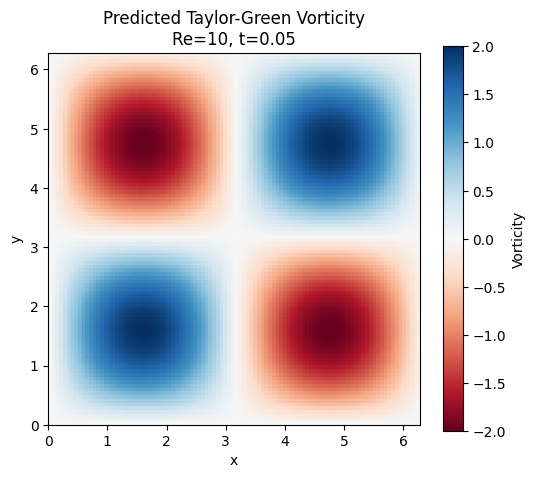

In [ ]:
plt.figure(figsize=(6,5))

plt.imshow(
    wm,
    extent=[0, L, 0, B],
    origin="lower",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Predicted Taylor-Green Vorticity\nRe={1/nu:.0f}, t={T}")

plt.show()

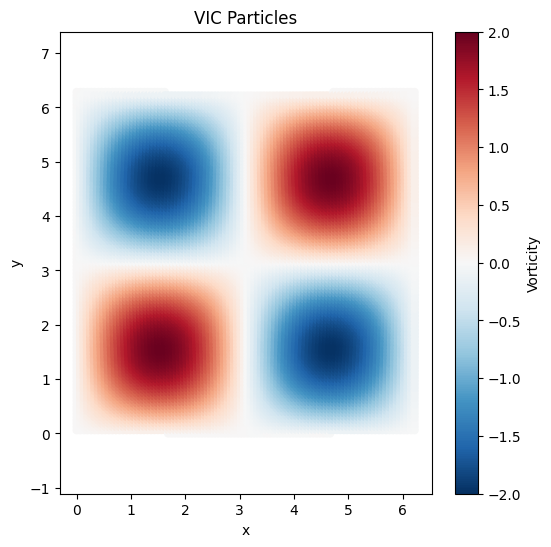

In [22]:
def plot_vic_particles(particles, h, title="VIC Particles"):

    x = np.array([p["pos"].real for p in particles])
    y = np.array([p["pos"].imag for p in particles])

    # Convert circulation back to vorticity
    w = np.array([p["a"] for p in particles]) / h**2

    #vmax = np.max(np.abs(w))

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        y,
        c=w,
        cmap="RdBu_r",
        s=25,
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)

    plt.show()

plot_vic_particles(particles, h)

In [17]:
import pickle
import os

if os.path.exists("data.pkl"):
    with open("data.pkl", "rb") as f:
        data = pickle.load(f)
else:
    data = {}

data["predicted"] = wm

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

Fourier Mode Analysis
Vorticity matrix shape : (100, 100)
Nx                     : 100
Ny                     : 100
dx                     : 6.283185e-02
dy                     : 6.283185e-02


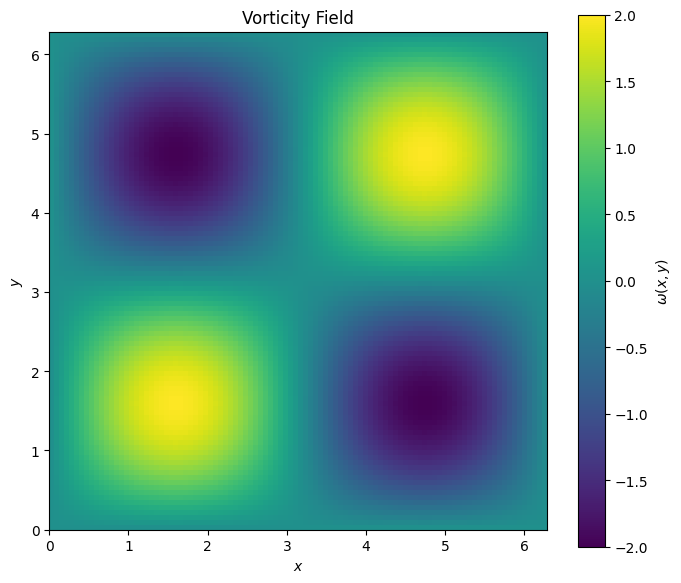

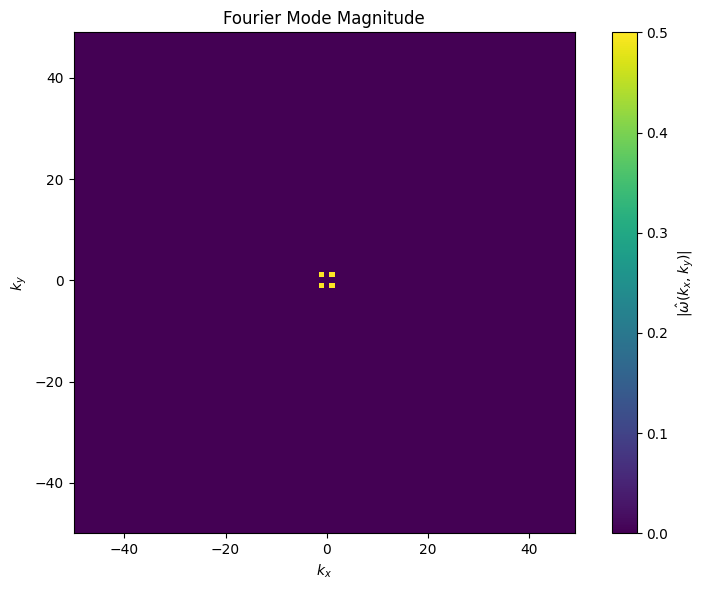

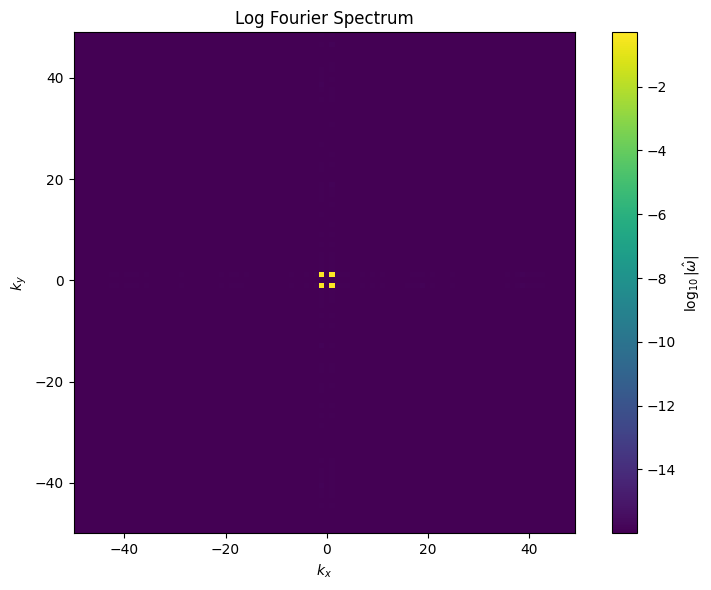

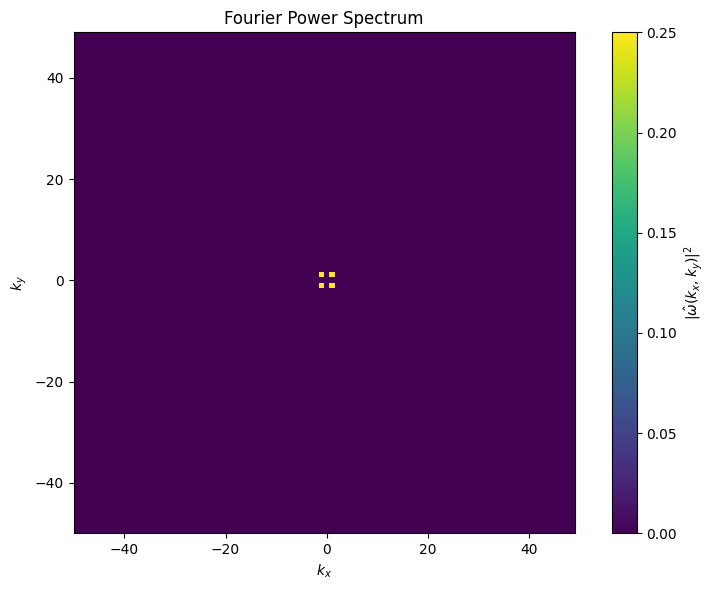

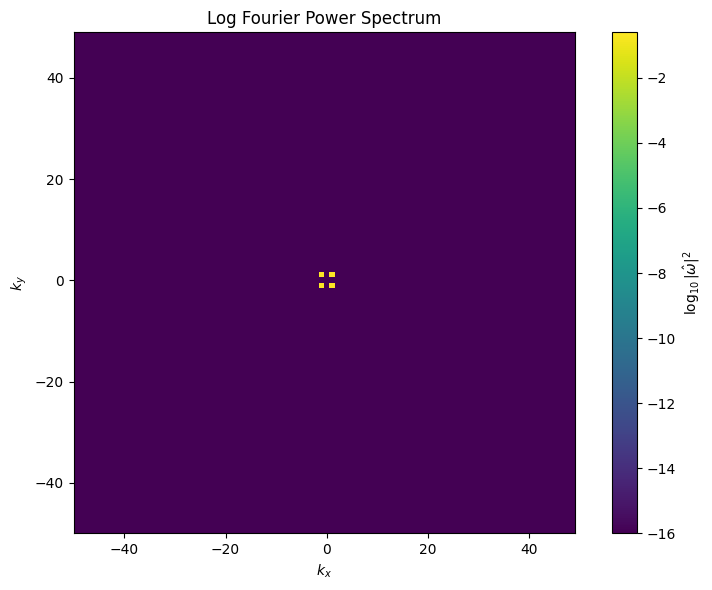

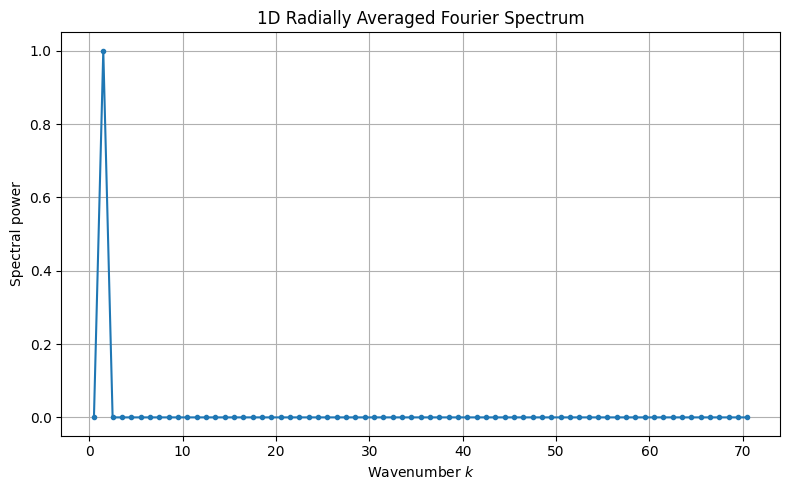

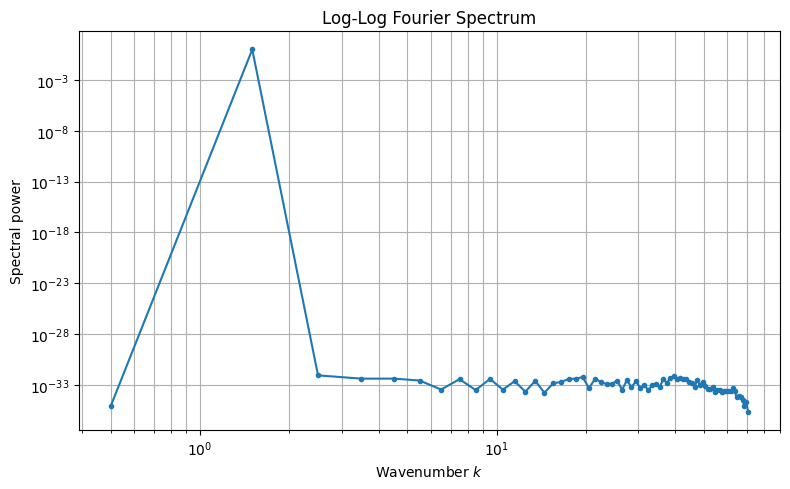



Dominant Fourier Modes
Rank    kx        ky        |omega_hat|       
------------------------------------------------------------
1       -1.00     -1.00     5.000000e-01      
2       1.00      1.00      5.000000e-01      
3       -1.00     1.00      5.000000e-01      
4       1.00      -1.00     5.000000e-01      
5       39.00     -1.00     4.821273e-17      
6       47.00     1.00      4.218984e-17      
7       -41.00    -1.00     4.112831e-17      
8       1.00      39.00     3.630882e-17      
9       19.00     1.00      3.601263e-17      
10      -1.00     -2.00     3.526525e-17      
11      1.00      2.00      3.526525e-17      
12      1.00      -2.00     3.524337e-17      
13      -1.00     2.00      3.524337e-17      
14      -1.00     39.00     3.456417e-17      
15      -1.00     19.00     3.434718e-17      


Strongest Fourier Mode
kx                 = 1.0000
ky                 = 1.0000
|omega_hat|        = 5.000000e-01


Spectral Statistics
Total spectral power = 1.

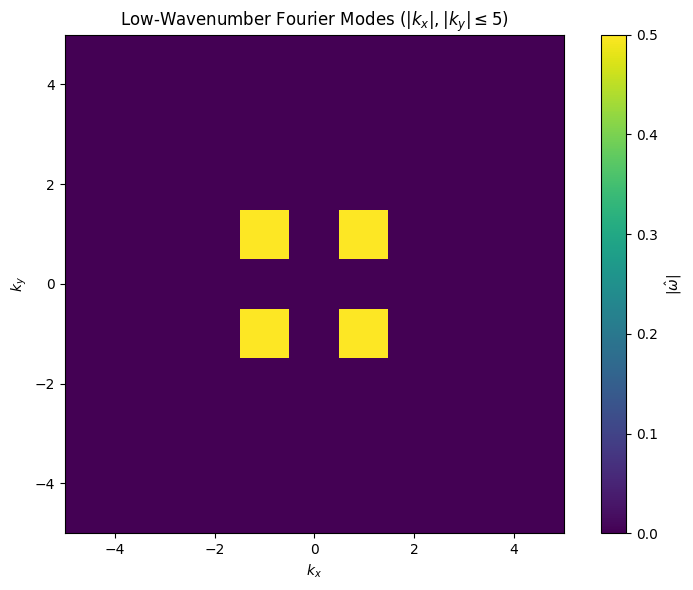



Analysis Complete


In [133]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FOURIER MODE ANALYSIS OF A 2D VORTICITY FIELD
# ============================================================

# ------------------------------------------------------------
# 1. INPUT YOUR VORTICITY MATRIX HERE
# ------------------------------------------------------------

# Example:
# omega = wm

# Replace this with your actual matrix
omega = wm


# ------------------------------------------------------------
# 2. DOMAIN PARAMETERS
# ------------------------------------------------------------

# Your Taylor-Green domain
L = 2 * np.pi       # domain length in x
B = 2 * np.pi       # domain length in y

Nx, Ny = omega.shape

dx = L / Nx
dy = B / Ny

print("============================================================")
print("Fourier Mode Analysis")
print("============================================================")
print(f"Vorticity matrix shape : {omega.shape}")
print(f"Nx                     : {Nx}")
print(f"Ny                     : {Ny}")
print(f"dx                     : {dx:.6e}")
print(f"dy                     : {dy:.6e}")


# ------------------------------------------------------------
# 3. PHYSICAL-SPACE GRID
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy

X, Y = np.meshgrid(x, y, indexing="ij")


# ------------------------------------------------------------
# 4. ORIGINAL VORTICITY FIELD
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    omega,
    extent=[0, L, 0, B],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$\omega(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Vorticity Field")

plt.tight_layout()
plt.show()


# ============================================================
# FOURIER TRANSFORM
# ============================================================

# ------------------------------------------------------------
# 5. 2D FFT
# ------------------------------------------------------------

omega_hat = np.fft.fft2(omega)

# Shift zero-frequency mode to the center
omega_hat_shifted = np.fft.fftshift(omega_hat)


# ------------------------------------------------------------
# 6. WAVENUMBERS
# ------------------------------------------------------------

kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

kx_shifted = np.fft.fftshift(kx)
ky_shifted = np.fft.fftshift(ky)

KX, KY = np.meshgrid(
    kx_shifted,
    ky_shifted,
    indexing="ij"
)


# ------------------------------------------------------------
# 7. NORMALIZED FOURIER COEFFICIENTS
# ------------------------------------------------------------

# Normalization makes the coefficient magnitude independent
# of the number of grid points.

omega_hat_normalized = omega_hat / (Nx * Ny)

omega_hat_shifted_normalized = np.fft.fftshift(
    omega_hat_normalized
)


# ============================================================
# FOURIER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 8. FOURIER MODE MAGNITUDE
# ------------------------------------------------------------

fourier_magnitude = np.abs(
    omega_hat_shifted_normalized
)

plt.figure(figsize=(8, 6))

plt.imshow(
    fourier_magnitude,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$|\hat{\omega}(k_x,k_y)|$")

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Mode Magnitude")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. LOG FOURIER SPECTRUM
# ------------------------------------------------------------

# Log scale makes weak modes visible.

log_spectrum = np.log10(
    fourier_magnitude + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# POWER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 10. FOURIER POWER
# ------------------------------------------------------------

power_spectrum = fourier_magnitude ** 2

plt.figure(figsize=(8, 6))

plt.imshow(
    power_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$|\hat{\omega}(k_x,k_y)|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. LOG POWER SPECTRUM
# ------------------------------------------------------------

log_power = np.log10(
    power_spectrum + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_power,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# RADIAL / 1D FOURIER SPECTRUM
# ============================================================

# This converts the 2D spectrum into a spectrum as a function
# of total wavenumber:
#
#       k = sqrt(kx^2 + ky^2)
#
# This is often the most useful spectrum for turbulence analysis.


# ------------------------------------------------------------
# 12. WAVENUMBER MAGNITUDE
# ------------------------------------------------------------

K = np.sqrt(KX**2 + KY**2)


# ------------------------------------------------------------
# 13. CREATE WAVENUMBER BINS
# ------------------------------------------------------------

k_max = int(np.ceil(K.max()))

k_bins = np.arange(
    0,
    k_max + 1
)

k_spectrum = np.zeros(len(k_bins) - 1)


# ------------------------------------------------------------
# 14. BIN FOURIER POWER
# ------------------------------------------------------------

for i in range(len(k_bins) - 1):

    mask = (
        (K >= k_bins[i]) &
        (K < k_bins[i + 1])
    )

    k_spectrum[i] = np.sum(
        power_spectrum[mask]
    )


k_values = 0.5 * (
    k_bins[:-1] +
    k_bins[1:]
)


# ------------------------------------------------------------
# 15. PLOT 1D RADIAL SPECTRUM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_spectrum,
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")
plt.title("1D Radially Averaged Fourier Spectrum")

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. LOG-LOG RADIAL SPECTRUM
# ------------------------------------------------------------

# Ignore zero values for log-log plotting.

mask = k_spectrum > 0

plt.figure(figsize=(8, 5))

plt.loglog(
    k_values[mask],
    k_spectrum[mask],
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")

plt.title("Log-Log Fourier Spectrum")

plt.grid(True, which="both")

plt.tight_layout()
plt.show()


# ============================================================
# DOMINANT FOURIER MODES
# ============================================================

# ------------------------------------------------------------
# 17. FIND LARGEST MODES
# ------------------------------------------------------------

magnitude_original = np.abs(
    omega_hat_normalized
)

flat_indices = np.argsort(
    magnitude_original.ravel()
)[::-1]


print("\n")
print("============================================================")
print("Dominant Fourier Modes")
print("============================================================")

print(
    f"{'Rank':<8}"
    f"{'kx':<10}"
    f"{'ky':<10}"
    f"{'|omega_hat|':<18}"
)

print("------------------------------------------------------------")


number_of_modes = 15

for rank, flat_index in enumerate(
    flat_indices[:number_of_modes],
    start=1
):

    i, j = np.unravel_index(
        flat_index,
        magnitude_original.shape
    )

    print(
        f"{rank:<8}"
        f"{kx[i]:<10.2f}"
        f"{ky[j]:<10.2f}"
        f"{magnitude_original[i,j]:<18.6e}"
    )


# ============================================================
# STRONGEST MODE
# ============================================================

# ------------------------------------------------------------
# 18. SINGLE STRONGEST MODE
# ------------------------------------------------------------

max_index = np.unravel_index(
    np.argmax(magnitude_original),
    magnitude_original.shape
)

i_max, j_max = max_index

dominant_kx = kx[i_max]
dominant_ky = ky[j_max]

dominant_value = magnitude_original[
    i_max,
    j_max
]


print("\n")
print("============================================================")
print("Strongest Fourier Mode")
print("============================================================")

print(f"kx                 = {dominant_kx:.4f}")
print(f"ky                 = {dominant_ky:.4f}")

print(
    f"|omega_hat|        = "
    f"{dominant_value:.6e}"
)


# ============================================================
# TOTAL SPECTRAL POWER
# ============================================================

# ------------------------------------------------------------
# 19. TOTAL POWER
# ------------------------------------------------------------

total_power = np.sum(
    power_spectrum
)

print("\n")
print("============================================================")
print("Spectral Statistics")
print("============================================================")

print(
    f"Total spectral power = "
    f"{total_power:.6e}"
)


# ============================================================
# CHECK FOR ZERO MODE
# ============================================================

# The zero mode represents the spatial mean of vorticity.

zero_mode = omega_hat_normalized[0, 0]

mean_vorticity = np.mean(omega)

print(
    f"Mean vorticity       = "
    f"{mean_vorticity:.6e}"
)

print(
    f"Zero Fourier mode    = "
    f"{zero_mode.real:.6e}"
)


# ============================================================
# OPTIONAL: SHOW ONLY LOW WAVENUMBER MODES
# ============================================================

# This is particularly useful for Taylor-Green vortex,
# because the important modes are usually at small k.

k_limit = 5

low_k_mask = (
    (np.abs(KX) <= k_limit) &
    (np.abs(KY) <= k_limit)
)

low_k_spectrum = np.where(
    low_k_mask,
    fourier_magnitude,
    np.nan
)

plt.figure(figsize=(8, 6))

plt.imshow(
    low_k_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.xlim(-k_limit, k_limit)
plt.ylim(-k_limit, k_limit)

plt.colorbar(
    label=r"$|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")

plt.title(
    f"Low-Wavenumber Fourier Modes "
    f"($|k_x|,|k_y| \leq {k_limit}$)"
)

plt.tight_layout()
plt.show()


print("\n")
print("============================================================")
print("Analysis Complete")
print("============================================================")